In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('house_price_regression_dataset.csv')

In [ ]:
df.head(5)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
df.corr(numeric_only=True)['House_Price'].sort_values(ascending=False)

,House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


In [ ]:
df.drop(columns=['Lot_Size'], inplace=True)

In [ ]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,False
997,False
998,False


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [ ]:
y = df['House_Price']
X = df[['Square_Footage','Num_Bedrooms','Num_Bathrooms','Garage_Size', 'Neighborhood_Quality']]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
print(r2_score(y_test, predictions))
print(mean_squared_error(y_test, predictions))

0.9873368839442788
816249988.1018659


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

df[['Square_Footage','Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Garage_Size', 'Neighborhood_Quality']] = scaler.fit_transform(
    df[['Square_Footage','Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Garage_Size', 'Neighborhood_Quality']]
)

In [ ]:
X = df[['Square_Footage','Num_Bedrooms','Num_Bathrooms','Year_Built','Garage_Size','Neighborhood_Quality']]
y = (df['House_Price'])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(r2_score(y_test, y_pred))

0.9919107450493924


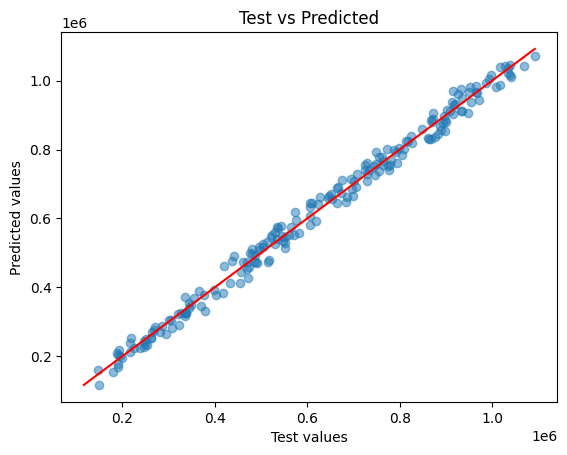

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val],color='red')
plt.xlabel("Test values")
plt.ylabel("Predicted values")
plt.title("Test vs Predicted")
plt.show()
